<a href="https://colab.research.google.com/github/gechsimxx-design/BCO7006---ASM-4-/blob/kevin/ASM_4_Group_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Cell 1: Import libraries and display settings**

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 105)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

**What it does:**\
This cell imports the main Python libraries used for data analysis, visualisation and statistical checking.

**Libraries used:**\
numpy is used for numerical calculations, especially log transformation.
pandas is used to load, clean and manage the data as tables.
matplotlib.pyplot and seaborn are used to create charts.
scipy.stats is used later to calculate Pearson correlation between house features and sale price.
warnings is used to hide warning messages so the notebook output is easier to read.

**pandas / numpy methods:**\
pd.set_option('max_columns', 105) changes the pandas display setting so that up to 105 columns can be shown when viewing the dataset.

**Loops / conditions:**\
There are no loops or conditions in this cell.

**Why it matters for the business:**\
This cell sets up the tools needed to inspect the housing data, clean it and identify patterns that may help predict house prices.

###**Cell 2: Set modelling options**

In [ ]:
nr_cv = 5

use_logvals = 1
target = 'SalePrice_Log'

min_val_corr = 0.4

drop_similar = 1

**What it does:**\
This cell sets important options used later in the notebook.

**Libraries used:**\
No external library is directly used in this cell. It creates Python variables.

**pandas / numpy methods:**\
No pandas or numpy methods are used in this cell.

**Loops / conditions:**\
There are no loops in this cell. However, drop_similar = 1 is used later in an if condition to decide whether similar highly correlated features should be removed.

**Explanation:**\
nr_cv = 5 means the notebook will use five-fold cross-validation when testing models.
use_logvals = 1 means the notebook will use log-transformed values.
target = 'SalePrice_Log' sets the prediction target as the log-transformed sale price.
min_val_corr = 0.4 means only features with correlation above 0.4 are treated as strong predictors.
drop_similar = 1 means the notebook will remove some features that repeat similar information.

**Why it matters for the business:**\
These settings control how strict the model is when selecting useful property features for price prediction.

###**Cell 3: Define helper function for model score**

In [ ]:
def get_best_score(grid):

    best_score = np.sqrt(-grid.best_score_)
    print(best_score)
    print(grid.best_params_)
    print(grid.best_estimator_)

    return best_score

**What it does:**\
This function extracts and prints the best model score, best parameters and best model from a GridSearchCV result.

**Libraries used:**\
numpy is used through np.sqrt().

**pandas / numpy methods:**\
np.sqrt() calculates the square root. The notebook uses negative mean squared error during model testing, so -grid.best_score_ converts it back into a positive value before calculating RMSE.

**Loops / conditions:**\
There are no loops or conditions in this function.

**Why it matters for the business:**\
This function helps compare models using RMSE. A lower RMSE means the predicted house prices are closer to the actual prices.

###**Cell 4: Define helper function for correlation matrix**

In [ ]:
def plot_corr_matrix(df, nr_c, targ) :

    corr = df.corr()
    corr_abs = corr.abs()
    cols = corr_abs.nlargest(nr_c, targ)[targ].index
    cm = np.corrcoef(df[cols].values.T)

    plt.figure(figsize=(nr_c/1.5, nr_c/1.5))
    sns.set(font_scale=1.25)
    sns.heatmap(cm, linewidths=1.5, annot=True, square=True,
                fmt='.2f', annot_kws={'size': 10},
                yticklabels=cols.values, xticklabels=cols.values
               )
    plt.show()

**What it does:**\
This function creates a heatmap showing the strongest correlations between selected features and the target variable.

**Libraries used:**\
pandas is used to calculate correlations.
numpy is used to create the correlation matrix.
matplotlib and seaborn are used to create the heatmap.

**pandas / numpy methods:**
* df.corr() calculates correlation between numerical columns.
* .abs() converts correlation values into positive numbers so strong negative and positive relationships can both be compared.
* .nlargest() selects the strongest correlations.
* .index returns the selected column names.
* np.corrcoef() calculates the correlation coefficient matrix.
* .values.T converts the selected DataFrame values into a transposed numerical array.

Loops / conditions:
There are no explicit loops or conditions in this function.

Why it matters for the business:
This helps identify which house features are most strongly connected with sale price, such as quality, living area, garage capacity and basement size.

###**Cell 5: Load the train and test datasets**

In [ ]:
df_train = pd.read_csv("https://raw.githubusercontent.com/gechsimxx-design/BCO7006---ASM-4-/refs/heads/main/train.csv")
df_test = pd.read_csv("https://raw.githubusercontent.com/gechsimxx-design/BCO7006---ASM-4-/refs/heads/main/test.csv")

**What it does:**\
This cell loads the training and testing datasets into Python.

**Libraries used:**\
pandas is used to read the CSV files and store them as DataFrames.

**pandas / numpy methods:**\
pd.read_csv() reads a CSV file and converts it into a pandas DataFrame. A DataFrame is a table with rows and columns.

**Loops / conditions:**\
There are no loops or conditions in this cell.

**Why it matters for the business:**\
This is the starting point of the analysis. The training data is used to learn from past house sales, while the testing data is used to predict unknown sale prices.

###**Cell 6: Check dataset size and structure**

In [ ]:
print(df_train.shape)
print("*"*50)
print(df_test.shape)

print(df_train.info())
print("*"*50)
print(df_test.info())

(1460, 81)
**************************************************
(1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non

**What it does:**\
This cell checks the number of rows and columns in the training and testing datasets. It also shows column names, data types and missing values.

**Libraries used:**\
pandas is used because df_train and df_test are DataFrames.

**pandas / numpy methods:**\
* df_train.shape returns the number of rows and columns in the training data.
* df_test.shape returns the number of rows and columns in the testing data.
* .info() shows the column names, data types and number of non-missing values.

**Loops / conditions:**\
There are no loops or conditions in this cell.

**Why it matters for the business:**\
This confirms that the data has loaded correctly. It also shows that the training data has SalePrice, while the test data does not. This is important because the model must learn from known sale prices and then predict unknown ones.

###**Cell 7: Preview and summarise the data**

In [ ]:
df_train.head()
df_train.describe()


df_test.head()
df_test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,1458.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1457.000000,1457.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.00000,1381.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,52.619342,554.294925,1046.117970,1156.534613,325.967786,3.543523,1486.045922,0.434454,0.065202,1.570939,0.377656,2.854010,1.042495,6.385195,0.58122,1977.721217,1.766118,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,176.753926,437.260486,442.898624,398.165820,420.610226,44.043251,485.566099,0.530648,0.252468,0.555190,0.503017,0.829788,0.208472,1.508895,0.64742,26.431175,0.775945,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000,0.000000,407.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.00000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,219.250000,784.000000,873.500000,0.000000,0.000000,1117.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.00000,1959.000000,1.000000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,0.000000,460.000000,988.000000,1079.000000,0.000000,0.000000,1432.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.00000,1979.000000,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,0.000000,797.750000,1305.000000,1382.500000,676.000000,0.000000,1721.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.00000,2002.000000,2.000000,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,1526.000000,2140.000000,5095.000000,5095.000000,1862.000000,1064.000000,5095.000000,3.000000,2.000000,4.000000,2.000000,6.000000,2.000000,15.000000,4.00000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


**What it does:**\
This cell displays sample rows and summary statistics for the training and testing datasets.

**Libraries used:**\
pandas is used to view and summarise the DataFrames.

**pandas / numpy methods:**
* .head() displays the first five rows of the dataset.
* .describe() returns summary statistics for numerical columns, including count, mean, standard deviation, minimum, quartiles and maximum.

**Loops / conditions:**\
There are no loops or conditions in this cell.

**Why it matters for the business:**\
This helps the analyst understand the range of house features and prices. For example, it shows the average sale price, the lowest sale price and the highest sale price in the training data.

**Cell 8: Analyse the target variable SalePrice**

Skewness:1.882876
Kurtosis:6.536282


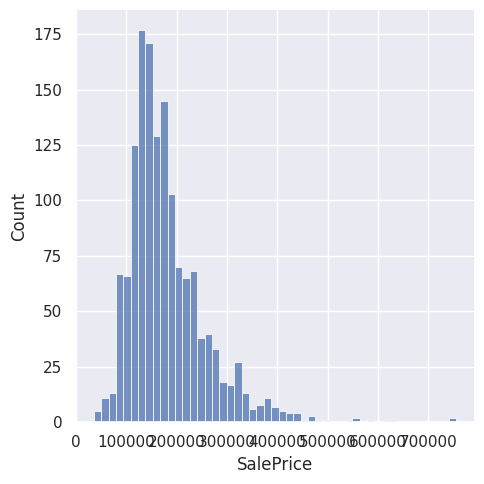

In [ ]:
sns.displot(df_train['SalePrice']);

print("Skewness:%f" % df_train['SalePrice'].skew())
print("Kurtosis:%f" % df_train['SalePrice'].kurt())


**What it does:**
This cell checks the distribution of house sale prices.

**Libraries used:**
seaborn is used to create the distribution plot.
pandas is used to calculate skewness and kurtosis.

**pandas / numpy methods:**
.skew() measures whether the sale prices are evenly distributed or pulled toward one side.
.kurt() measures whether the data has many extreme values.

**Loops / conditions:**
There are no loops or conditions in this cell.

**Why it matters for the business:**
This shows that most homes are in a lower-to-middle price range, while a smaller number of homes are much more expensive. These high-value homes can affect prediction accuracy if they are not handled carefully.


**Cell 9: Log-transform SalePrice**

Skewness: 0.121335
Kurtosis: 0.809532


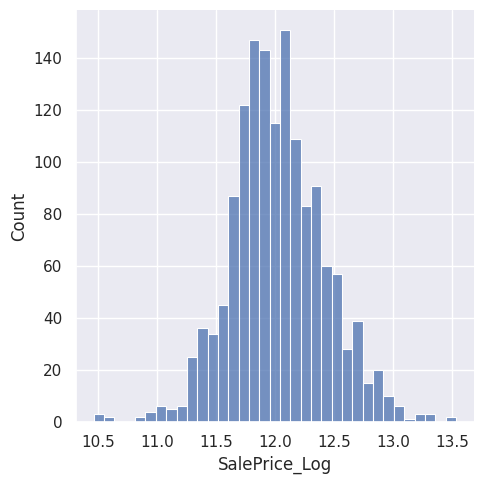

In [ ]:
df_train['SalePrice_Log'] = np.log(df_train['SalePrice'])

sns.displot(df_train['SalePrice_Log']);

print("Skewness: %f" % df_train['SalePrice_Log'].skew())
print("Kurtosis: %f" % df_train['SalePrice_Log'].kurt())

df_train.drop('SalePrice',axis=1, inplace=True)

**What it does:**
This cell creates a log-transformed version of SalePrice and removes the original SalePrice column.

**Libraries used:**
numpy is used for the log calculation.
seaborn is used to visualise the transformed distribution.
pandas is used to calculate skewness and kurtosis and to remove the original column.

**pandas / numpy methods:**
np.log() converts sale price into log scale.
.skew() checks whether the transformed prices are more balanced.
.kurt() checks whether extreme values have been reduced.
.drop() removes the original SalePrice column.
axis=1 means a column is removed.
inplace=True means the change is applied directly to df_train.

**Loops / conditions:**
There are no loops or conditions in this cell.

**Why it matters for the business:**
The log transformation reduces the impact of extremely expensive houses. This helps the model focus on general price patterns instead of being dominated by outliers.


**Cell 10: Separate numerical and categorical features**

In [ ]:
numerical_feats = df_train.dtypes[df_train.dtypes != "object"].index
print("Number of numerical features: ", len(numerical_feats))

categorical_feats = df_train.dtypes[df_train.dtypes == "object"].index
print("Number of categorical features: ", len(categorical_feats))

Number of numerical features:  38
Number of categorical features:  43


**What it does:**
 This cell separates the dataset into numerical features and categorical features.

**Libraries used:**
 pandas is used to check the data type of each column.

**pandas / numpy methods:**
.dtypes returns the data type of each column.
.index returns the column names that match the condition.
len() counts how many features are in each group.

**Loops / conditions:**
There is no explicit loop.
The conditions df_train.dtypes != "object" and df_train.dtypes == "object" filter the columns into numerical and categorical groups.

**Why it matters for the business:**
 This matters because numerical and categorical features need different preparation. For example, the house area is already numerical, but the neighbourhood is text and must be transformed before modelling.


**Cell 11: Check missing values**

In [ ]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageQual,81,0.055479
GarageFinish,81,0.055479
GarageType,81,0.055479


**What it does:**
This cell checks which columns have missing values and calculates the percentage of missing data.

**Libraries used:**
pandas is used to check, count, sort and combine missing-value information.

**pandas / numpy methods:**
.isnull() marks missing cells as True.
.sum() counts how many missing values each column has.
.count() counts non-missing values.
.sort_values(ascending=False) sorts columns from most missing values to least.
pd.concat() combines the missing-value count and percentage into one table.
.head(20) displays the first 20 rows.

**Loops / conditions:**
There are no loops or conditions in this cell.

**Why it matters for the business:**
Missing data can reduce the reliability of the analysis. This cell identifies which property features need cleaning before the models are trained.

**Cell 12: Fill missing categorical values**

In [ ]:
Cols_fillna =  ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
               'GarageQual','GarageCond','GarageFinish','GarageType', 'Electrical',
               'KitchenQual', 'SaleType', 'Functional', 'Exterior2nd', 'Exterior1st',
               'BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','BsmtFinType2',
               'MSZoning', 'Utilities']

for col in Cols_fillna:
   df_train[col].fillna('None',inplace=True)
   df_test[col].fillna('None',inplace=True)


**What it does:
This cell replaces missing values with "None" for selected categorical columns.

**Libraries used:**
pandas is used to fill missing values in the DataFrames.

**pandas / numpy methods:**
.fillna('None') replaces missing values with the text "None".
inplace=True applies the change directly to the original DataFrame.

**Loops / conditions:**
The for col in cols_fillna: loop repeats the same missing-value replacement for every column in the list.

**Why it matters for the business:**
In some columns, a missing value has meaning. For example, missing PoolQC can mean the house does not have a pool. Replacing these missing values with "None" preserves useful business information.

**Cell 13: Fill remaining missing values with the mean**

In [ ]:
df_train.fillna(df_train.mean(), inplace=True)
df_test.fillna(df_test.mean(), inplace=True)


df_train.isnull().sum().sum()
df_test.isnull().sum().sum()

TypeError: Could not convert ['RLRLRLRLRLRLRLRLRMRLRLRLRLRLRLRMRLRLRLRLRLRMRLRMRLRLRLRLRLRMC (all)RLRLRLRLRLRLRLRLRLRLRLRLRLRLRLRLFVRMRLRLRMRMRLRLRLFVRLRLRLRLRMRLRMRLRLRLRLRMRLRLRLRLRLRMRMRLRMRLRMRLRMRLRLRLRLRLFVC (all)RLRLRLRLC (all)RLRLRLRLRLRLRLRLRLRLRMFVRMRMRMRLRLRLRLRLRLFVRLRLRLRLRLRMRLRLRLRMRLRMRLRLRLRLRLRLRLRLRLRLRLRLRLRLRLRLRMRMRMRLRLRMRLRLRLRLRMRLRLRLFVRLRLRLRLRLRMRLRLRLRLRLRMRLRLRLRLRLRLRLRLRMFVRLRLRMRLRMRLRLRLRLRLRLRLRMRLRLRLRLRMRLRMRLRLRMRMRLRLRLRLRLRLRLFVRLRLRLRLRMRLRLRLRLRLRLRLRMRLRMRLRLRLRLRMRLRLRMRLRLRLRLFVRMRMRLRLRLRMRLRLRLRLRMRLRLRLRLFVRLRLRMRLRLRLRMRMRLRLRLRMRLFVRLRLRLRLRLRLRLRLRLRLFVRLRLRLFVRLRLRLRLRLRLRLRLRLRLRMFVRLRLRLRLRLRLRMRLRLRMRLRLRLRLRMRLRMRLRLFVRLRLRLRLRLRMRLRMRLRLRLRMRLRLRLRMRLRLRLRLRLRLRLRHRLRLRMRLRLRLRLRLRLRLRLRMRLRLRLRMRLRLRLRLRLRMRLRMRLRLRLRLRLRLRLRLRLRLRLFVRLRLRLFVRLRHRLRLRLRLRLRLRLRLRLRLRLRLRLRLRMFVRLRLRLRLRLRLRLRLRLFVRLRLFVRMRLRLRLRLRLRLRMRLRLRLRLRMRLRLRLRLRMRMRMRLRMRLRMRMRLRLRLRLRMRLRLRLRLRLRMRMRMRLRLFVRLRLRMRLRMRLFVRLRLRLRLRMRLRLRLRLRLRLRMRLRLRLRL

**What it does:**
This cell fills remaining missing numerical values using the column average and checks whether any missing values remain.

**Libraries used:**
pandas is used to fill missing values and check the final missing-value count.

**pandas / numpy methods:**
.fillna() replaces missing values.
.mean() calculates the average value of each numerical column.
.isnull().sum().sum() counts the total number of missing values left in the whole DataFrame.

**Loops / conditions:**
There are no loops or conditions in this cell.

**Why it matters for the business:**
The models need complete data. Filling missing values makes the dataset ready for analysis and modelling.

**Cell 14: Check skewness and kurtosis for numerical features**

In [ ]:
for col in numerical_feats:
    print('{:15}'.format(col),
          'Skewness: {:05.2f}'.format(df_train[col].skew()) ,
          '   ' ,
          'Kurtosis: {:06.2f}'.format(df_train[col].kurt())
         )

Id              Skewness: 00.00     Kurtosis: -01.20
MSSubClass      Skewness: 01.41     Kurtosis: 001.58
LotFrontage     Skewness: 02.16     Kurtosis: 017.45
LotArea         Skewness: 12.21     Kurtosis: 203.24
OverallQual     Skewness: 00.22     Kurtosis: 000.10
OverallCond     Skewness: 00.69     Kurtosis: 001.11
YearBuilt       Skewness: -0.61     Kurtosis: -00.44
YearRemodAdd    Skewness: -0.50     Kurtosis: -01.27
MasVnrArea      Skewness: 02.67     Kurtosis: 010.08
BsmtFinSF1      Skewness: 01.69     Kurtosis: 011.12
BsmtFinSF2      Skewness: 04.26     Kurtosis: 020.11
BsmtUnfSF       Skewness: 00.92     Kurtosis: 000.47
TotalBsmtSF     Skewness: 01.52     Kurtosis: 013.25
1stFlrSF        Skewness: 01.38     Kurtosis: 005.75
2ndFlrSF        Skewness: 00.81     Kurtosis: -00.55
LowQualFinSF    Skewness: 09.01     Kurtosis: 083.23
GrLivArea       Skewness: 01.37     Kurtosis: 004.90
BsmtFullBath    Skewness: 00.60     Kurtosis: -00.84
BsmtHalfBath    Skewness: 04.10     Kurtosis: 

**What it does:**
This cell checks the distribution shape of every numerical feature.

**Libraries used:**
 pandas is used to calculate skewness and kurtosis.

**pandas / numpy methods:**
.skew() measures whether a feature is unevenly distributed.
.kurt() measures whether a feature contains many extreme values.

**Loops / conditions:**
The for col in numerical_feats: loop repeats the same calculation for every numerical column.

**Why it matters for the business:**
This helps identify property features with extreme values, such as very large land size or living area. These features may need transformation before modelling.

**Cell 15: Log-transform selected property features**

In [ ]:
for df in [df_train, df_test]:
    df['GrLivArea_Log'] = np.log(df['GrLivArea'])
    df.drop('GrLivArea', inplace= True, axis = 1)
    df['LotArea_Log'] = np.log(df['LotArea'])
    df.drop('LotArea', inplace= True, axis = 1)

**What it does:
This cell creates log-transformed versions of GrLivArea and LotArea for both the training and testing datasets.

**Libraries used:**
numpy is used for log transformation.
pandas is used to create and remove columns.

**pandas / numpy methods:**
np.log() converts the original values into log scale.
.drop() removes the original columns after the log versions are created.
axis=1 means columns are removed.
inplace=True applies the changes directly.

**Loops / conditions:** The for df in [df_train, df_test]: loop repeats the same transformation for both datasets.

**Why it matters for the business:**
This reduces the effect of very large houses or land areas, making the data more balanced for price prediction.

**Cell 16: Plot numerical features against SalePrice_Log**

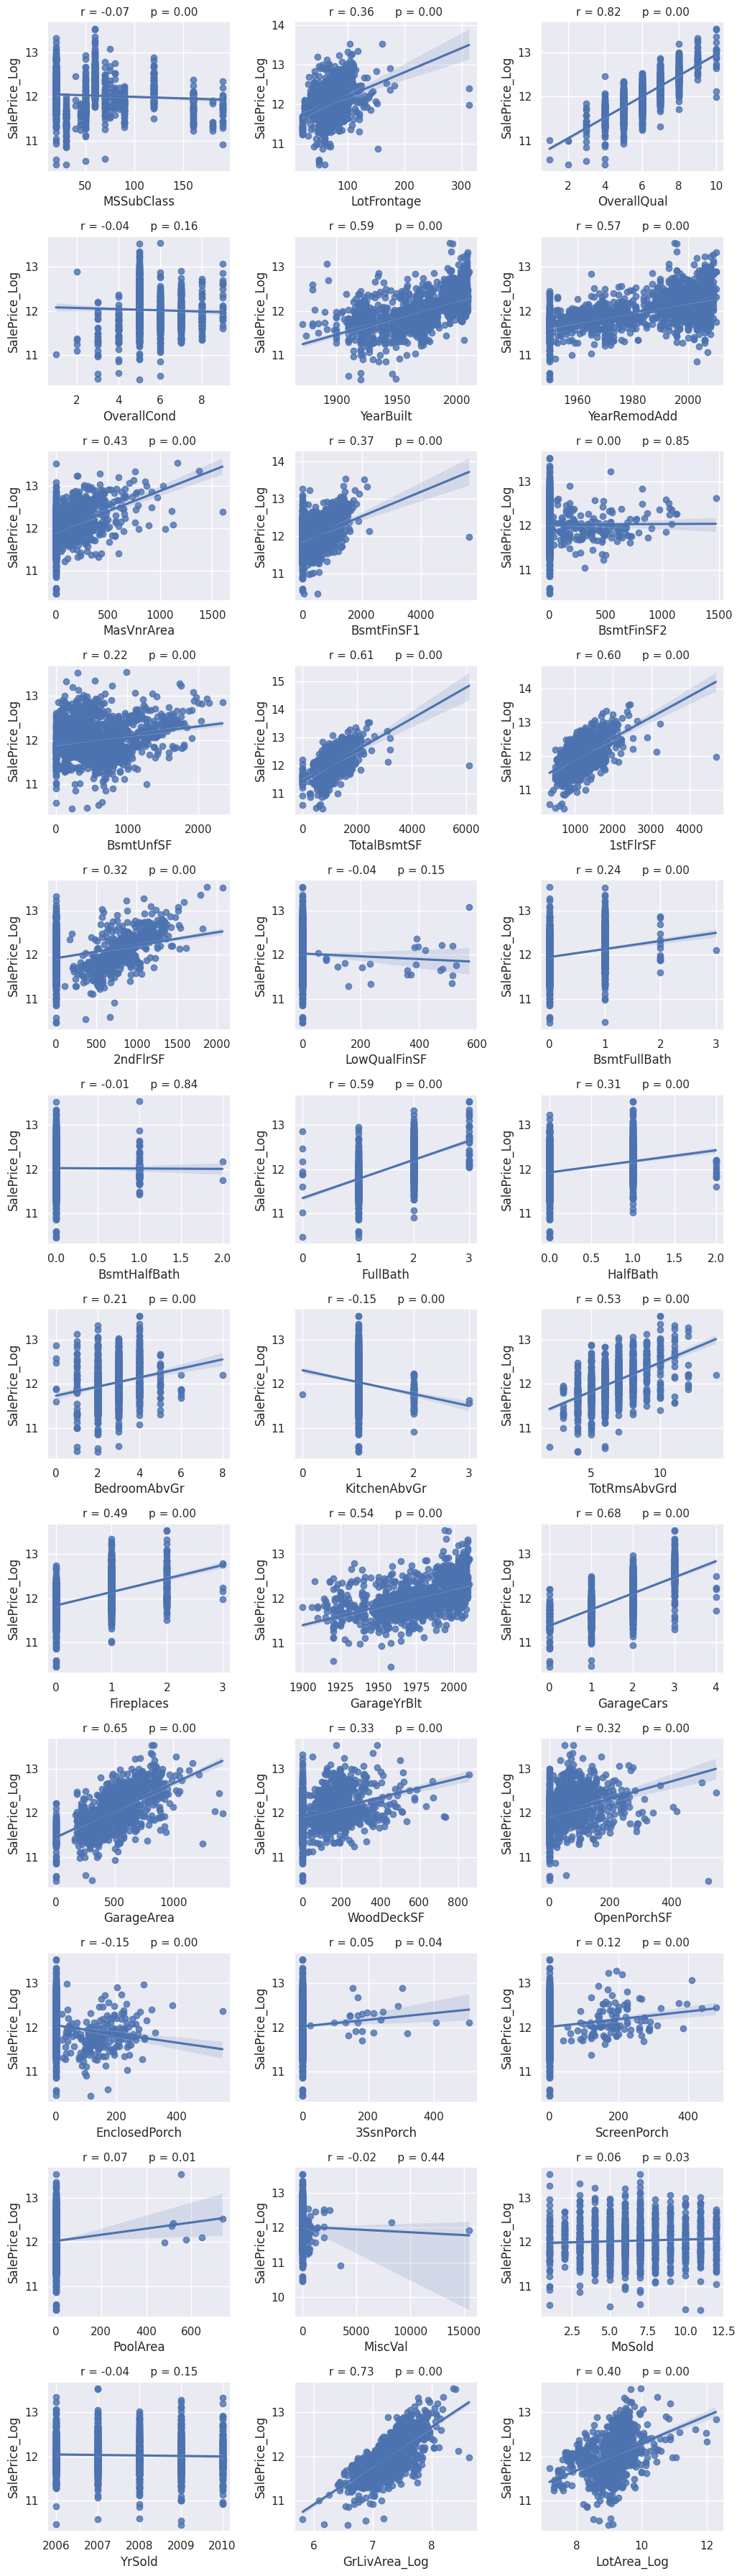

In [ ]:
nr_rows = 12
nr_cols = 3


fig, axs = plt.subplots(nr_rows, nr_cols, figsize=(nr_cols*3.5, nr_rows*3))


li_not_plot = ['Id', 'SalePrice', 'SalePrice_Log']

# Redefine numerical_feats to reflect the current state of df_train
current_numerical_feats = df_train.select_dtypes(include=np.number).columns
li_plot_num_feats = [c for c in list(current_numerical_feats) if c not in li_not_plot]


for r in range(0, nr_rows):
    for c in range(0, nr_cols):
        i = r * nr_cols + c

        if i < len(li_plot_num_feats):
            feature = li_plot_num_feats[i]


            plot_data = df_train[[feature, target]].copy()
            plot_data = plot_data.replace([np.inf, -np.inf], np.nan)
            plot_data = plot_data.dropna()


            if len(plot_data) > 1 and plot_data[feature].nunique() > 1:
                sns.regplot(
                    x=plot_data[feature],
                    y=plot_data[target],
                    ax=axs[r][c]
                )


                stp = stats.pearsonr(plot_data[feature], plot_data[target])
                str_title = "r = " + "{0:.2f}".format(stp[0]) + "      p = " + "{0:.2f}".format(stp[1])
                axs[r][c].set_title(str_title, fontsize=11)
            else:
                axs[r][c].set_title(feature + " skipped", fontsize=11)


plt.tight_layout()
plt.show()

**What it does:
This cell creates a grid of regression plots to compare each numerical house feature with SalePrice_Log. It helps show which numerical features have a strong or weak relationship with house price. Each plot also shows the correlation value between the feature and the target variable.

**Libraries used:**
matplotlib.pyplot is used to create the grid of subplots, adjust the layout, add the main title and display the final figure.
seaborn is used to create the regression plots and generate a colour palette.
scipy.stats is used to calculate Pearson correlation between each numerical feature and SalePrice_Log.

**pandas / numpy methods:**
This cell mainly uses pandas to select numerical columns from the training dataset. It creates a list of numerical features and removes columns such as Id, SalePrice, and SalePrice_Log because these should not be plotted as input features. Pandas column selection is also used to choose one feature at a time from df_train for each chart.
There are no major NumPy methods used in this cell. The main data-handling work is selecting columns from the pandas DataFrame and preparing the list of features that will be plotted.

**Loops / conditions:**
This cell uses two loops. The first loop goes through the rows of the chart grid, and the second loop goes through the columns. Together, these loops allow the notebook to create many charts automatically instead of writing separate chart code for every feature.
The condition if i < len(li_plot_num_feats) checks whether there is still a feature left to plot. If there is a feature available, the code creates a regression plot and calculates the correlation value. This prevents the notebook from trying to create a chart when there are no more features left.

**Why it matters for the business:**
This cell helps identify which house features are more useful for predicting house prices. Features with stronger relationships to SalePrice_Log are more likely to help the model estimate property values accurately. This supports better pricing decisions for real estate businesses.

**Cell 17: Select correlated features and create correlation heatmap**

In [ ]:
corr = df_train.corr()
corr_abs = corr.abs()


nr_num_cols = len(numerical_feats)
ser_corr = corr_abs.nlargest(nr_num_cols, target)[target]


cols_abv_corr_limit = list(ser_corr[ser_corr.values > min_val_corr].index)
cols_bel_corr_limit = list(ser_corr[ser_corr.values <= min_val_corr].index)
nr_feats = len(cols_abv_corr_limit)
plot_corr_matrix(df_train, nr_feats, target)

ValueError: could not convert string to float: 'RL'

**What it does:**
This cell creates a correlation heatmap for the features that have a stronger relationship with SalePrice_Log. It first counts how many features are above the minimum correlation limit, then uses the plot_corr_matrix() function to display those features in a heatmap.

**Libraries used:**
pandas is used inside the plot_corr_matrix() function to calculate correlations between numerical columns.
numpy is used inside the function to create the correlation coefficient matrix.
matplotlib.pyplot and seaborn are used inside the function to display the heatmap.

**pandas / numpy methods:**

- len(cols_abv_corr_limit) counts how many features passed the minimum correlation threshold

- plot_corr_matrix(df_train, nr_feats, target) calls the helper function created earlier in the notebook.
- Inside that function, .corr() calculates the correlation between numerical features.
- .abs() changes correlation values into positive values so strong relationships are easier to compare.
- .nlargest() selects the features with the strongest correlation to the target variable.
- np.corrcoef() creates the correlation matrix used in the heatmap.

**Loops / conditions:**
There are no loops or if/else conditions in these two lines. However, the features shown in the heatmap are based on the earlier correlation condition from Cell 17a, where only features above the minimum correlation value are selected.

**Why it matters for the business:**
This heatmap helps identify which property features are most strongly connected with house price. For example, features such as overall quality, living area, garage capacity and basement size may show stronger relationships with SalePrice_Log. This helps real estate businesses understand which house characteristics are most useful when estimating property value.

**Cell 18: Convert selected categorical features into numbers**

In [ ]:
# 'MSZoning'
msz_catg2 = ['RM', 'RH']
msz_catg3 = ['RL', 'FV']


# Neighborhood
nbhd_catg2 = ['Blmngtn', 'ClearCr', 'CollgCr', 'Crawfor', 'Gilbert',
              'NWAmes', 'Somerst', 'Timber', 'Veenker']
nbhd_catg3 = ['NoRidge', 'NridgHt', 'StoneBr']


# Condition2
cond2_catg2 = ['Norm', 'RRAe']
cond2_catg3 = ['PosA', 'PosN']


# SaleType
SlTy_catg1 = ['Oth']
SlTy_catg3 = ['CWD']
SlTy_catg4 = ['New', 'Con']


for df in [df_train, df_test]:

    df['MSZ_num'] = 1
    df.loc[(df['MSZoning'].isin(msz_catg2)), 'MSZ_num'] = 2
    df.loc[(df['MSZoning'].isin(msz_catg3)), 'MSZ_num'] = 3

    df['NbHd_num'] = 1
    df.loc[(df['Neighborhood'].isin(nbhd_catg2)), 'NbHd_num'] = 2
    df.loc[(df['Neighborhood'].isin(nbhd_catg3)), 'NbHd_num'] = 3


    df['Cond2_num'] = 1
    df.loc[(df['Condition2'].isin(cond2_catg2)), 'Cond2_num'] = 2
    df.loc[(df['Condition2'].isin(cond2_catg3)), 'Cond2_num'] = 3

    df['Mas_num'] = 1
    df.loc[(df['MasVnrType'] == 'Stone'), 'Mas_num'] = 2

    df['ExtQ_num'] = 1
    df.loc[(df['ExterQual'] == 'TA'), 'ExtQ_num'] = 2
    df.loc[(df['ExterQual'] == 'Gd'), 'ExtQ_num'] = 3
    df.loc[(df['ExterQual'] == 'Ex'), 'ExtQ_num'] = 4

    df['BsQ_num'] = 1
    df.loc[(df['BsmtQual'] == 'Gd'), 'BsQ_num'] = 2
    df.loc[(df['BsmtQual'] == 'Ex'), 'BsQ_num'] = 3

    df['CA_num'] = 0
    df.loc[(df['CentralAir'] == 'Y'), 'CA_num'] = 1


    df['Elc_num'] = 1
    df.loc[(df['Electrical'] == 'SBrkr'), 'Elc_num'] = 2


    df['KiQ_num'] = 1
    df.loc[(df['KitchenQual'] == 'TA'), 'KiQ_num'] = 2
    df.loc[(df['KitchenQual'] == 'Gd'), 'KiQ_num'] = 3
    df.loc[(df['KitchenQual'] == 'Ex'), 'KiQ_num'] = 4

    df['SlTy_num'] = 2
    df.loc[(df['SaleType'].isin(SlTy_catg1)), 'SlTy_num'] = 1
    df.loc[(df['SaleType'].isin(SlTy_catg3)), 'SlTy_num'] = 3
    df.loc[(df['SaleType'].isin(SlTy_catg4)), 'SlTy_num'] = 4

**What it does:**
This cell changes selected text-based features into numerical features. For example, columns such as MSZoning, Neighborhood, ExterQual, BsmtQual, KitchenQual, and SaleType contain text categories. The notebook converts these into new number columns so they can be used by the machine learning models.

**Libraries used:**
This cell mainly uses pandas because it works with the df_train and df_test DataFrames.

**pandas / numpy methods:**
The cell uses pandas to create new columns such as MSZ_num, NbHd_num, ExtQ_num, BsQ_num, KiQ_num, and SlTy_num. It uses .loc[] to update rows that match certain conditions, and .isin() to check whether a category is inside a list. No major NumPy method is used in this cell.

**Loops / conditions:**
The loop runs through both df_train and df_test, so the same changes are applied to both datasets. This is important because the training and testing data must have the same feature format. The .loc[] lines act like conditions. For example, if a house belongs to a certain neighbourhood group, the notebook gives it a matching number.

**Why it matters for the business:**
Machine learning models work better with numbers than text. By converting important property information such as neighbourhood, zoning, kitchen quality and sale type into numbers, the model can use these features to help predict house prices.